In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/heart-disease1.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [5]:
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Shape: (303, 13)

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
dtype: object

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64

Number of duplicate rows:
1


In [6]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)
print("Duplicates remaining:", df.duplicated().sum())

Shape after removing duplicates: (302, 13)
Duplicates remaining: 0


In [8]:
from sklearn.preprocessing import StandardScaler

X = df.copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

Original shape: (302, 13)
Scaled shape: (302, 13)


In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)

    results.append([k, inertia, silhouette])

results_df = pd.DataFrame(
    results,
    columns=["k", "Inertia", "Silhouette"]
)

results_df

,k,Inertia,Silhouette
0,2,3317.824499,0.168060
1,3,3071.421743,0.114382
2,4,2861.629339,0.119309
3,5,2714.036922,0.118789
4,6,2608.679255,0.112373
5,7,2522.213504,0.103440
6,8,2455.369627,0.086069


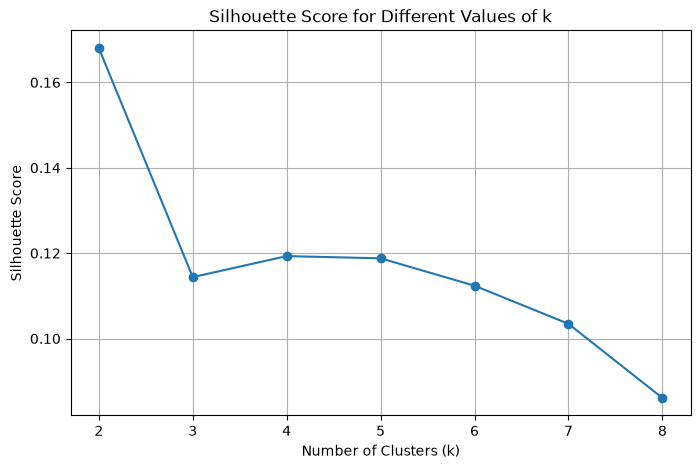

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["k"],
    results_df["Silhouette"],
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different Values of k")
plt.xticks(results_df["k"])
plt.grid(True)

plt.show()

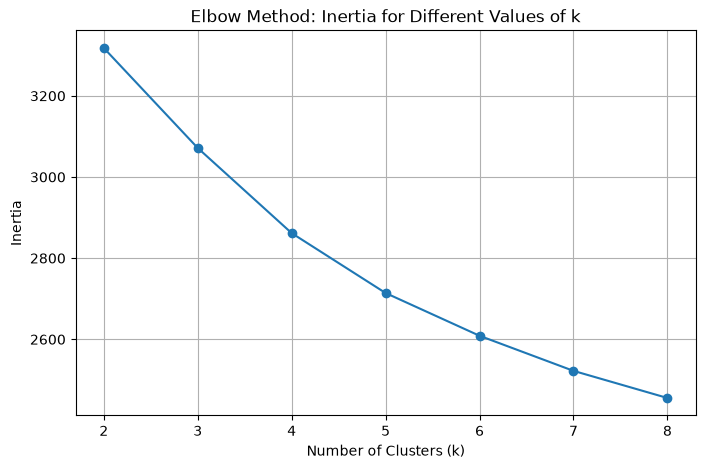

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    results_df["k"],
    results_df["Inertia"],
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method: Inertia for Different Values of k")
plt.xticks(results_df["k"])
plt.grid(True)

plt.show()


In [15]:
from sklearn.utils import resample
from sklearn.metrics import adjusted_rand_score

stability_results = []

for k in range(2, 9):
    # Clustering on the full dataset
    full_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    full_labels = full_model.fit_predict(X_scaled)

    ari_scores = []

    # Repeat on bootstrap samples
    for seed in range(20):
        sample_indices = resample(
            range(len(X_scaled)),
            replace=True,
            random_state=seed
        )

        X_sample = X_scaled[sample_indices]

        sample_model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )
        sample_labels = sample_model.fit_predict(X_sample)

        # Compare bootstrap clustering with full clustering
        ari = adjusted_rand_score(
            full_labels[sample_indices],
            sample_labels
        )

        ari_scores.append(ari)

    stability_results.append([
        k,
        sum(ari_scores) / len(ari_scores)
    ])

stability_df = pd.DataFrame(
    stability_results,
    columns=["k", "Mean ARI Stability"]
)

stability_df

,k,Mean ARI Stability
0,2,0.855797
1,3,0.586221
2,4,0.676258
3,5,0.607759
4,6,0.552212
5,7,0.505011
6,8,0.458496


In [19]:
for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")

age: 41 unique values
sex: 2 unique values
cp: 4 unique values
trestbps: 49 unique values
chol: 152 unique values
fbs: 2 unique values
restecg: 3 unique values
thalach: 91 unique values
exang: 2 unique values
oldpeak: 40 unique values
slope: 3 unique values
ca: 5 unique values
thal: 4 unique values


In [20]:
continuous_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

X_continuous = df[continuous_features]

scaler_gmm = StandardScaler()
X_gmm = scaler_gmm.fit_transform(X_continuous)

print("Features used for GMM:")
print(continuous_features)

print("\nShape:", X_gmm.shape)

Features used for GMM:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

Shape: (302, 5)


In [21]:
# Split the unscaled continuous data first
X_train_raw, X_test_raw = train_test_split(
    X_continuous,
    test_size=0.20,
    random_state=42
)

# Fit the scaler ONLY on training data
scaler_gmm = StandardScaler()

X_train_gmm = scaler_gmm.fit_transform(X_train_raw)
X_test_gmm = scaler_gmm.transform(X_test_raw)

print("Training data:", X_train_gmm.shape)
print("Held-out data:", X_test_gmm.shape)

Training data: (241, 5)
Held-out data: (61, 5)


In [22]:
from sklearn.mixture import GaussianMixture

gmm_results = []

for k in range(1, 9):
    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )

    gmm.fit(X_train_gmm)

    train_score = gmm.score(X_train_gmm)
    heldout_score = gmm.score(X_test_gmm)

    gmm_results.append([
        k,
        train_score,
        heldout_score
    ])

gmm_results_df = pd.DataFrame(
    gmm_results,
    columns=[
        "Components",
        "Training Log-Likelihood",
        "Held-out Log-Likelihood"
    ]
)

gmm_results_df

,Components,Training Log-Likelihood,Held-out Log-Likelihood
0,1,-6.861866,-6.991130
1,2,-5.023458,-4.950517
2,3,-4.855719,-5.023536
3,4,-4.726909,-5.008830
4,5,-4.642054,-5.329003
5,6,-4.461546,-5.104163
6,7,-4.360422,-5.412705
7,8,-4.376830,-5.506035


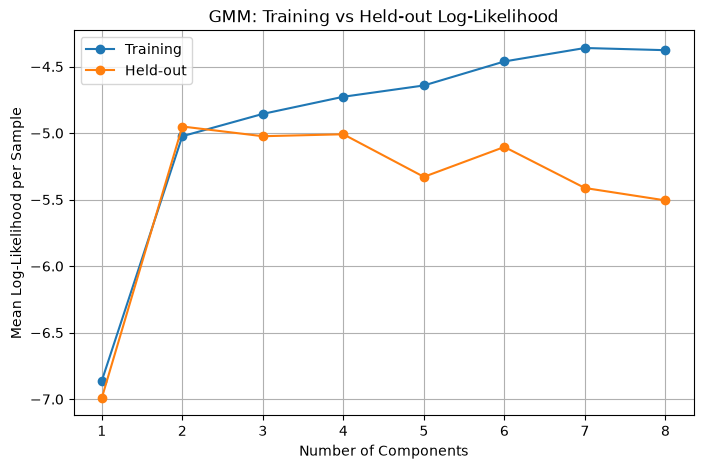

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    gmm_results_df["Components"],
    gmm_results_df["Training Log-Likelihood"],
    marker="o",
    label="Training"
)

plt.plot(
    gmm_results_df["Components"],
    gmm_results_df["Held-out Log-Likelihood"],
    marker="o",
    label="Held-out"
)

plt.xlabel("Number of Components")
plt.ylabel("Mean Log-Likelihood per Sample")
plt.title("GMM: Training vs Held-out Log-Likelihood")
plt.xticks(gmm_results_df["Components"])
plt.legend()
plt.grid(True)

plt.show()

In [25]:
feature_variance = df.var().sort_values()

print("Feature variance:")
print(feature_variance)

Feature variance:
fbs            0.127225
sex            0.217553
exang          0.221084
restecg        0.276705
thal           0.375800
slope          0.379794
ca             1.013542
cp             1.065114
oldpeak        1.348971
age           81.865757
trestbps     308.472817
thalach      524.571561
chol        2678.423588
dtype: float64


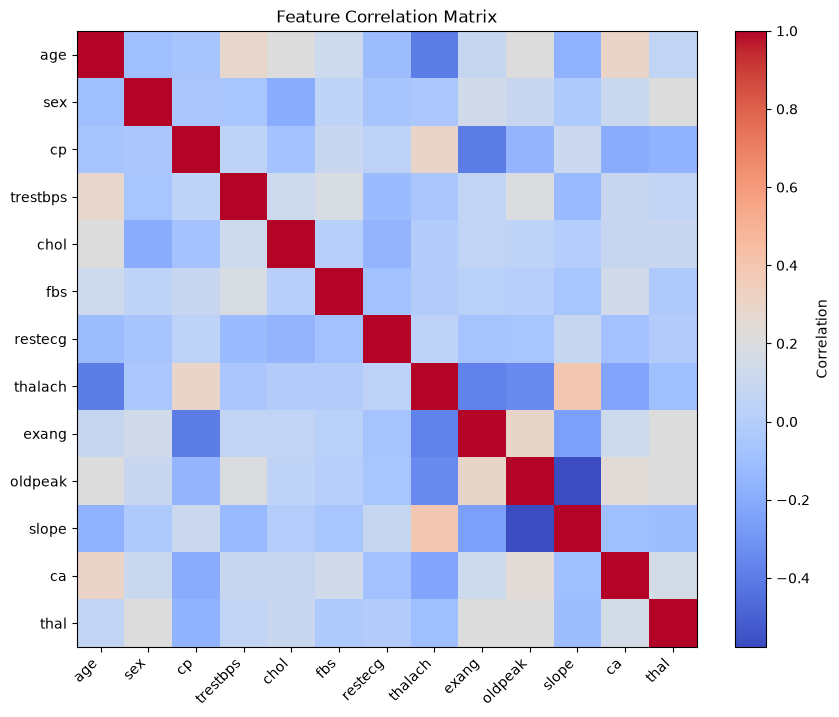

In [27]:
import matplotlib.pyplot as plt

correlation = df.corr()

plt.figure(figsize=(10, 8))

plt.imshow(correlation, cmap="coolwarm", aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Feature Correlation Matrix")

plt.show()

In [28]:
correlation = df.corr()

high_corr = []

for i in range(len(correlation.columns)):
    for j in range(i + 1, len(correlation.columns)):
        value = correlation.iloc[i, j]

        if abs(value) >= 0.30:
            high_corr.append([
                correlation.columns[i],
                correlation.columns[j],
                value
            ])

high_corr_df = pd.DataFrame(
    high_corr,
    columns=["Feature 1", "Feature 2", "Correlation"]
)

high_corr_df.sort_values(
    "Correlation",
    key=abs,
    ascending=False
)

,Feature 1,Feature 2,Correlation
6,oldpeak,slope,-0.576314
0,age,thalach,-0.395235
2,cp,exang,-0.392937
5,thalach,slope,0.384754
3,thalach,exang,-0.377411
4,thalach,oldpeak,-0.342201
1,age,ca,0.302261


In [29]:
# Baseline: all 13 features
X_all = df.copy()

# Pruned version: remove slope
X_pruned = df.drop(columns=["slope"])

print("All features:", X_all.shape)
print("Pruned features:", X_pruned.shape)
print("\nRemoved feature: slope")

All features: (302, 13)
Pruned features: (302, 12)

Removed feature: slope


In [30]:
# Scale all 13 features
scaler_all = StandardScaler()
X_all_scaled = scaler_all.fit_transform(X_all)

# Scale the 12-feature pruned dataset
scaler_pruned = StandardScaler()
X_pruned_scaled = scaler_pruned.fit_transform(X_pruned)

print("All features:", X_all_scaled.shape)
print("Pruned features:", X_pruned_scaled.shape)

All features: (302, 13)
Pruned features: (302, 12)


In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# K-Means using all 13 features
kmeans_all = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels_all = kmeans_all.fit_predict(X_all_scaled)

silhouette_all = silhouette_score(
    X_all_scaled,
    labels_all
)

# K-Means using 12 features (without slope)
kmeans_pruned = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels_pruned = kmeans_pruned.fit_predict(X_pruned_scaled)

silhouette_pruned = silhouette_score(
    X_pruned_scaled,
    labels_pruned
)

print("Silhouette score - All features:", silhouette_all)
print("Silhouette score - Without slope:", silhouette_pruned)

Silhouette score - All features: 0.16806012892394878
Silhouette score - Without slope: 0.16525452276379507


In [32]:
# Remove oldpeak instead of slope
X_pruned_oldpeak = df.drop(columns=["oldpeak"])

# Standardize the pruned dataset
scaler_oldpeak = StandardScaler()
X_pruned_oldpeak_scaled = scaler_oldpeak.fit_transform(X_pruned_oldpeak)

print("Original features:", X_all.shape)
print("After removing oldpeak:", X_pruned_oldpeak.shape)
print("Removed feature: oldpeak")

Original features: (302, 13)
After removing oldpeak: (302, 12)
Removed feature: oldpeak


In [33]:
# K-Means without oldpeak
kmeans_oldpeak = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels_oldpeak = kmeans_oldpeak.fit_predict(
    X_pruned_oldpeak_scaled
)

silhouette_oldpeak = silhouette_score(
    X_pruned_oldpeak_scaled,
    labels_oldpeak
)

print("Silhouette score - All features:", silhouette_all)
print("Silhouette score - Without oldpeak:", silhouette_oldpeak)

Silhouette score - All features: 0.16806012892394878
Silhouette score - Without oldpeak: 0.15719567161639994


In [34]:
pruning_results = []

for feature in df.columns:
    
    # Remove one feature
    X_temp = df.drop(columns=[feature])
    
    # Scale after removing the feature
    scaler_temp = StandardScaler()
    X_temp_scaled = scaler_temp.fit_transform(X_temp)
    
    # K-Means with k=2
    kmeans_temp = KMeans(
        n_clusters=2,
        random_state=42,
        n_init=10
    )
    
    labels_temp = kmeans_temp.fit_predict(X_temp_scaled)
    
    # Calculate silhouette
    score = silhouette_score(
        X_temp_scaled,
        labels_temp
    )
    
    pruning_results.append([
        feature,
        score
    ])

pruning_df = pd.DataFrame(
    pruning_results,
    columns=["Removed Feature", "Silhouette Score"]
)

pruning_df.sort_values(
    "Silhouette Score",
    ascending=False
)

,Removed Feature,Silhouette Score
1,sex,0.182222
4,chol,0.180488
6,restecg,0.179676
5,fbs,0.178441
3,trestbps,0.176377
0,age,0.174991
12,thal,0.169140
11,ca,0.167426
10,slope,0.165255
2,cp,0.162696


In [35]:
from sklearn.utils import resample
from sklearn.metrics import adjusted_rand_score

# Full dataset clustering
kmeans_all = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)
labels_all = kmeans_all.fit_predict(X_all_scaled)

# Pruned dataset clustering
kmeans_no_sex = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)
labels_no_sex = kmeans_no_sex.fit_predict(
    X_pruned_scaled if "sex" not in X_pruned.columns else X_pruned_scaled
)

# Test stability using bootstrap samples
def calculate_stability(X_scaled, full_labels):
    ari_scores = []

    for seed in range(20):
        indices = resample(
            range(len(X_scaled)),
            replace=True,
            random_state=seed
        )

        X_sample = X_scaled[indices]

        model = KMeans(
            n_clusters=2,
            random_state=42,
            n_init=10
        )

        sample_labels = model.fit_predict(X_sample)

        ari = adjusted_rand_score(
            full_labels[indices],
            sample_labels
        )

        ari_scores.append(ari)

    return sum(ari_scores) / len(ari_scores)

stability_all = calculate_stability(
    X_all_scaled,
    labels_all
)

stability_no_sex = calculate_stability(
    X_pruned_scaled,
    labels_no_sex
)

print("Stability - All features:", stability_all)
print("Stability - Without sex:", stability_no_sex)

Stability - All features: 0.8557967291984354
Stability - Without sex: 0.9091210241833337


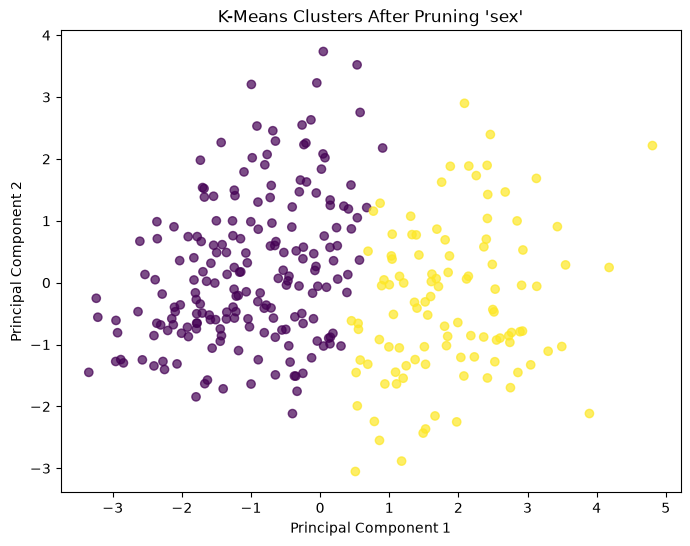

In [36]:
from sklearn.decomposition import PCA

# Create the final pruned dataset by removing sex
X_no_sex = df.drop(columns=["sex"])

# Standardize the 12 features
scaler_no_sex = StandardScaler()
X_no_sex_scaled = scaler_no_sex.fit_transform(X_no_sex)

# K-Means with the selected k = 2
kmeans_final = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

final_labels = kmeans_final.fit_predict(X_no_sex_scaled)

# Reduce to 2 dimensions only for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_no_sex_scaled)

# Plot the clusters
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=final_labels,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters After Pruning 'sex'")

plt.show()